# QMUL SBM BAAE PHD Introduction to geospatial analysis with Python

## Part 1 - Working with Shapefiles and Satellite Imagery

In this notebook, we will learn how to work with basic geospatial data formats, to load and inspact files and to work with some of the main geospatial packages



## Introduction

Geospatial analysis frequently combines:

* **Raster data** (satellite imagery such as Sentinel-2 or Landsat)
* **Vector data** (shapefiles containing polygons, points, or lines)

Typical operations include:

* Reading satellite imagery
* Reading shapefiles
* Reprojecting vector data
* Clipping imagery using polygons
* Computing statistics within regions of interest
* Rasterizing vector data
* Preparing training datasets for machine learning

This notebook demonstrates common workflows using Rasterio and GeoPandas.

# Installation

Install the required packages:

```bash
pip install rasterio geopandas shapely matplotlib numpy
```

In [7]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from rasterio.mask import mask
from rasterio.features import rasterize

# Data Structure

Assume the following directory structure:

```text
data/
├── sentinel_image.tif
└── region.shp
```

# 1. Loading Satellite Imagery

Rasterio provides efficient access to geospatial raster data.

In [9]:
image_path = "data/out1.tif"

with rasterio.open(image_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)

CRS: PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Width: 3847
Height: 2272
Bands: 4


The next step is moving from **reading metadata** about the raster to **reading actual pixel values**.

## What does `src.read(1)` do?

`read()` loads pixel values from the raster into a NumPy array.

The argument `1` specifies that we want to read **Band 1**.

```python
red_band = src.read(1)
```

After this line, `red_band` is no longer a Rasterio object—it is a standard NumPy array that can be processed using:

* NumPy
* Matplotlib
* Scikit-learn
* PyTorch
* TensorFlow

---

## Understanding raster bands

A satellite image usually contains multiple layers (bands).

For example, a simple RGB image:

| Band | Meaning |
| ---- | ------- |
| 1    | Red     |
| 2    | Green   |
| 3    | Blue    |


## Why read a single band?

Many remote sensing analyses operate band-by-band:

### NDVI

Uses:

```python
NIR = src.read(8)
RED = src.read(4)

ndvi = (NIR - RED) / (NIR + RED)
```

### Water indices

Use combinations of:

* Green
* NIR
* SWIR

### Machine Learning

Features often consist of:

```python
Band 2
Band 3
Band 4
Band 8
NDVI
Elevation
...
```

So reading individual bands is the first step in building geospatial ML pipelines.


This code below:

1. Opens the GeoTIFF.
2. Reads the first raster band.
3. Converts it into a NumPy array.
4. Stores the pixel values in `red_band`.
5. Makes the data ready for visualization, analysis, and machine learning.


In [10]:
#Read a single band:

with rasterio.open(image_path) as src:
    red_band = src.read(1)

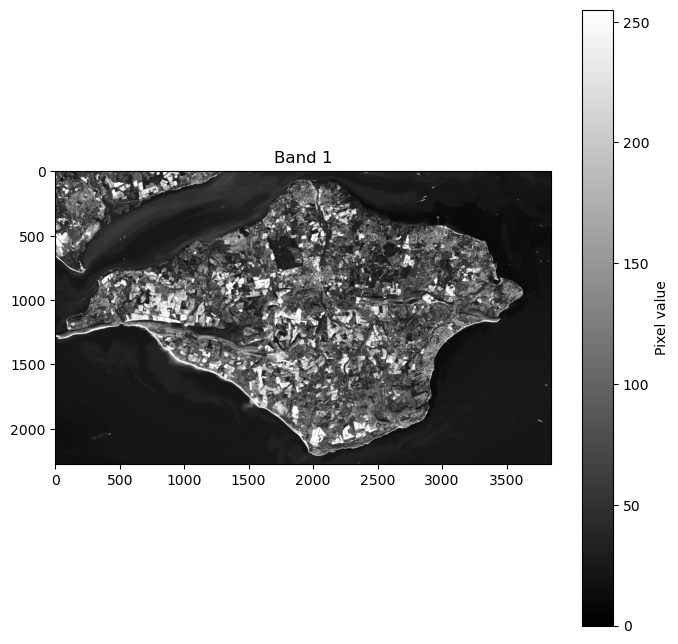

In [11]:
import matplotlib.pyplot as plt

with rasterio.open(image_path) as src:
    band1 = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel value")
plt.title("Band 1")
plt.show()

This file is a 4-band GeoTIFF file, it contains the follwing information: 

- Band 1 = Red
- Band 2 = Green
- Band 3 = Blue
- Band 4 = Alpha / transparency
- dtype  = uint8
- size   = 3847 × 2272 pixels
- CRS    = EPSG:32630

## Plot bands 1,2 and 3 separately

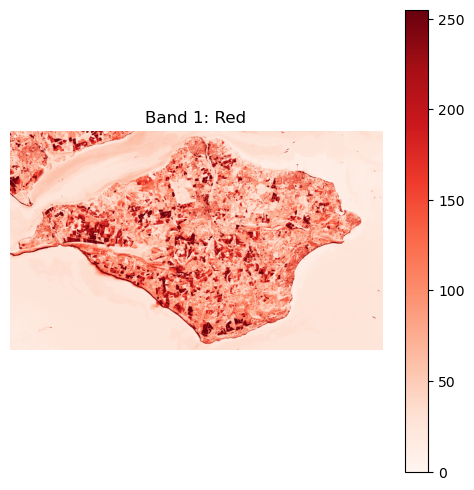

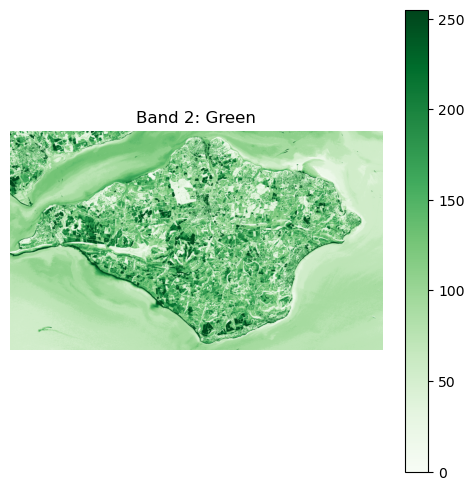

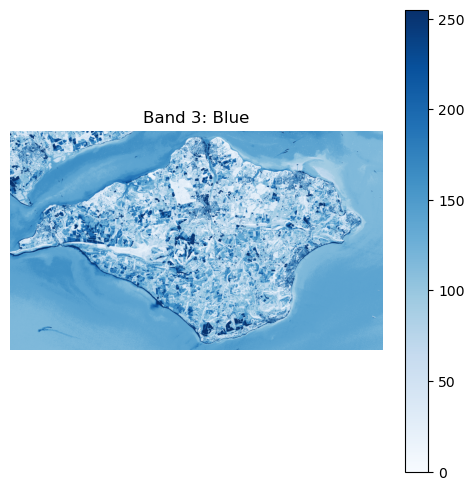

In [29]:
import rasterio
import matplotlib.pyplot as plt

image_path = "data/out1.tif"

with rasterio.open(image_path) as src:
    band1 = src.read(1)  # Red
    band2 = src.read(2)  # Green
    band3 = src.read(3)  # Blue

plt.figure(figsize=(6, 6))
plt.imshow(band1, cmap="Reds")
plt.title("Band 1: Red")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(band2, cmap="Greens")
plt.title("Band 2: Green")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(band3, cmap="Blues")
plt.title("Band 3: Blue")
plt.colorbar()
plt.axis("off")
plt.show()

### Plot bands 1, 2, and 3 together as RGB
Because this file is already `uint8` with values from `0–255`, you **do not need additional normalization** for RGB plotting.


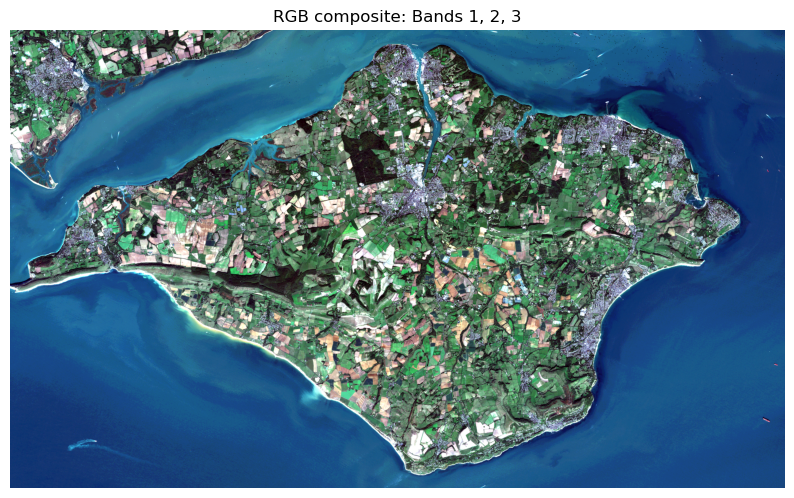

In [30]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

image_path = "data/out1.tif"

with rasterio.open(image_path) as src:
    red = src.read(1)
    green = src.read(2)
    blue = src.read(3)

rgb = np.dstack((red, green, blue))

plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title("RGB composite: Bands 1, 2, 3")
plt.axis("off")
plt.show()

## Opening a Sentinel-2 image

# Opening a Sentinel-2 GeoTIFF with Rasterio

In this notebook, we will load a clipped Sentinel-2 image using Rasterio and inspect its metadata.

A GeoTIFF contains:

- Pixel values representing spectral reflectance measurements
- Georeferencing information
- Coordinate Reference System (CRS)
- Spatial resolution
- Image dimensions

The first step in any remote sensing workflow is understanding the structure of the raster dataset before performing analysis.

In [3]:
import rasterio

image_path = "data/S2_may_South_coast_clip.tif"

with rasterio.open(image_path) as src:
    print(src)

<open DatasetReader name='data/S2_may_South_coast_clip.tif' mode='r'>


In [4]:
with rasterio.open(image_path) as src:
    
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Number of Bands:", src.count)
    print("Data Type:", src.dtypes)
    print("Bounds:", src.bounds)

CRS: EPSG:32630
Width: 751
Height: 519
Number of Bands: 13
Data Type: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
Bounds: BoundingBox(left=647800.0, bottom=5625850.0, right=655310.0, top=5631040.0)


## Understanding the Metadata

### CRS

The Coordinate Reference System (CRS) defines how image coordinates map to locations on Earth.

Sentinel-2 imagery is commonly distributed in UTM projections such as:

- EPSG:32630 (UTM Zone 30N)
- EPSG:32631 (UTM Zone 31N)

### Width and Height

These indicate the number of pixels in the image.

### Bands

Sentinel-2 contains multiple spectral bands measuring reflected energy in different wavelengths:

| Band  | Wavelength Region |
| ----- | ----------------- |
| B1    | Coastal aerosol   |
| B2    | Blue              |
| B3    | Green             |
| B4    | Red               |
| B5-B7 | Red Edge          |
| B8    | Near Infrared     |
| B8A   | Narrow NIR        |
| B9    | Water Vapor       |
| B10   | Cirrus            |
| B11   | SWIR 1            |
| B12   | SWIR 2            |

**Important:** Band numbering depends on the file.

`read(1)` means:

> "Read the first band stored in this GeoTIFF."

It does **not always mean "red band".**

You should check the metadata or documentation of the dataset.



### Bounds

The bounding coordinates define the geographic extent covered by the image.

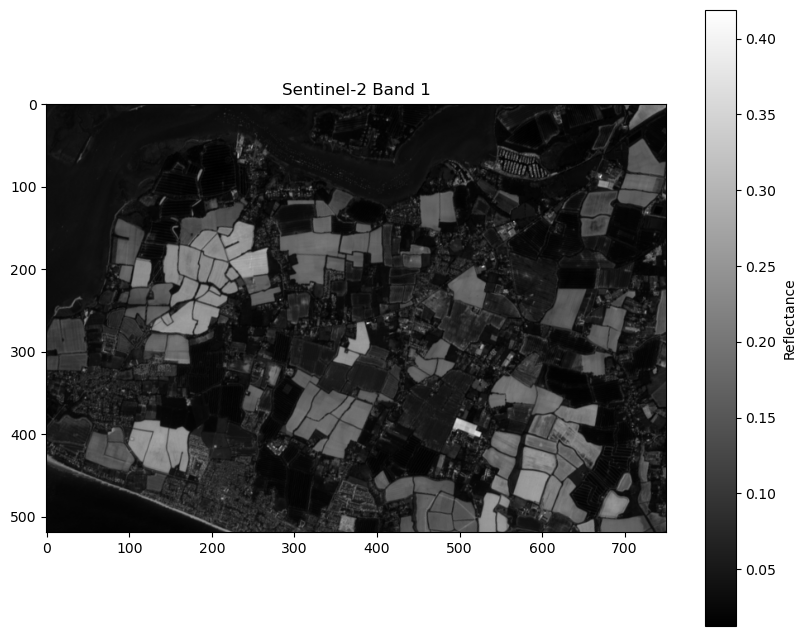

In [8]:
import matplotlib.pyplot as plt

with rasterio.open(image_path) as src:
    
    band1 = src.read(4)

plt.figure(figsize=(10, 8))
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Reflectance")
plt.title("Sentinel-2 Band 1")
plt.show()

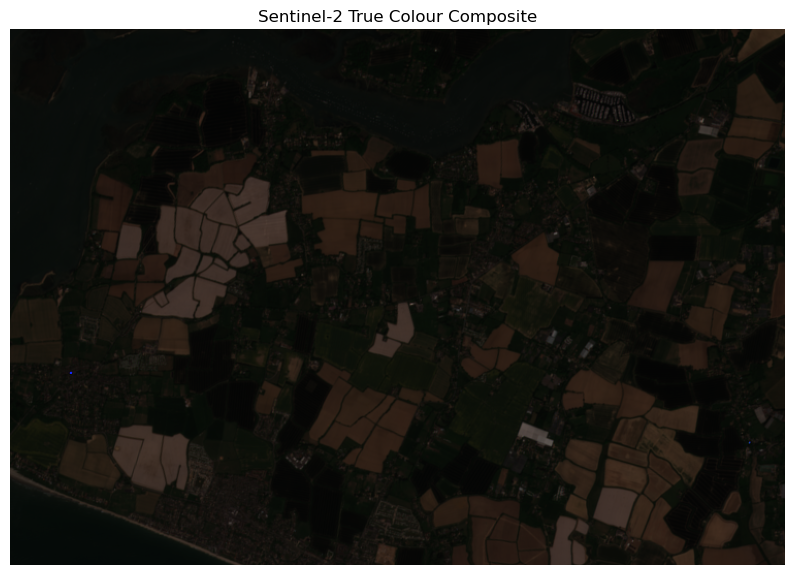

In [9]:
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(image_path) as src:

    red = src.read(4)
    green = src.read(3)
    blue = src.read(2)

rgb = np.dstack([red, green, blue])

rgb = rgb.astype(float)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Sentinel-2 True Colour Composite")
plt.axis("off")
plt.show()

## Displaying a Natural Colour Composite

For Sentinel-2 imagery:

| Band | Description |
|--------|------------|
| B4 | Red |
| B3 | Green |
| B2 | Blue |

Combining these bands produces an image similar to what the human eye would see.

This is often called a True Colour Composite (TCC).

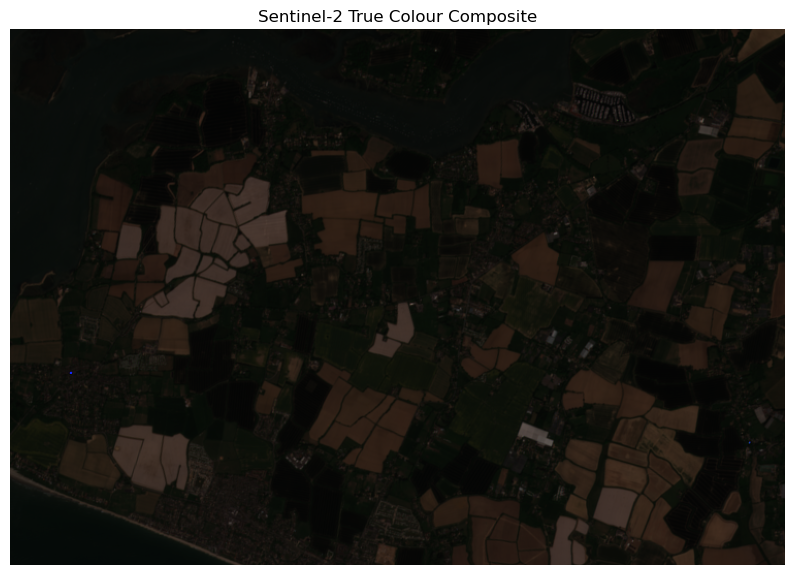

In [7]:
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(image_path) as src:

    red = src.read(4)
    green = src.read(3)
    blue = src.read(2)

rgb = np.dstack([red, green, blue])

rgb = rgb.astype(float)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Sentinel-2 True Colour Composite")
plt.axis("off")
plt.show()